In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("D:/prog/Data_Analyst_Pet_Projects/E-Commerce/data.csv", encoding="ISO-8859-1")


In [3]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2010 8:34,1.69,13047.0,United Kingdom


In [4]:
df.info

<bound method DataFrame.info of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

            InvoiceDate  UnitPrice  Custome

In [5]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


# Analysis of Columns Based on Descriptive Statistics

- `Column 'Quantity'`: Requires filtering of anomalous values (`Quantity < 0` - returns). Check for duplicate rows with the same `InvoiceNo` and `CustomerID` (possible errors).
  
- `Column 'UnitPrice'`: Remove rows with `UnitPrice < 0` (likely errors). Split prices into quantiles and analyze which products are too expensive.

- `Column 'CustomerID'`: Check rows without `CustomerID` (likely anonymous purchases). Find out how customers are distributed by the number of orders.

## Conclusions

  1. Clean the data — remove negative values in `Quantity` and `UnitPrice`.
  2. Analyze returns (`Quantity < 0`).
  3. Handle missing `CustomerID`.
  4. Build graphs to analyze the distribution of `Quantity` and `UnitPrice`.

In [6]:
df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

# Analysis of Column Types

  - `Column 'InvoiceNo'`: Invoice number - the user's order number, type 'object', which needs to be replaced with 'int64', as the column values are integers. Duplicates may exist.
    
  - `Column 'StockCode'`: Stock code, type 'object'. No type change is required. Further checks for duplicates will be performed.
     
  - `Column 'Description'`: Product description, type 'object' is correct.

  - `Column 'Quantity'`: Quantity of a specific product, type 'int64' is correct.

  - `Column 'InvoiceDate'`: Order date, type 'object' is incorrect, it needs to be replaced with 'datetime'..

  - `Column 'UnitPrice'`: Price per unit of the product, type 'float64' is correct.

  - `Column 'CustomerID'`: Unique customer identifier, type 'float64', which is better replaced with 'int64'.

  - `Column 'Country'`: Country of the order, type 'object' is correct.
    

In [7]:
df[['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']].isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
df['InvoiceNo'] = pd.to_numeric(df['InvoiceNo'], errors='coerce').astype('Int64')

In [9]:
df[df['InvoiceNo'].isna()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,<NA>,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,<NA>,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,<NA>,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,<NA>,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,<NA>,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,<NA>,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,12/9/2011 9:57,0.83,14397.0,United Kingdom
541541,<NA>,M,Manual,-1,12/9/2011 10:28,224.69,15498.0,United Kingdom
541715,<NA>,21258,VICTORIAN SEWING BOX LARGE,-5,12/9/2011 11:57,10.95,15311.0,United Kingdom
541716,<NA>,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,12/9/2011 11:58,1.25,17315.0,United Kingdom


In [10]:
df[df['StockCode'].isin(df[df['InvoiceNo'].isna()]['StockCode'].unique())] # understand which products are most frequently returned

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [11]:
returns_df = df[df['Quantity'] < 0] # extract returns into a separate dataframe (for analysis)

In [12]:
top_returns = returns_df.groupby('StockCode').agg({'Quantity': 'sum'}).reset_index() # aggregation by StockCode to calculate the number of returns

In [13]:
top_returns_sorted = top_returns.sort_values(by='Quantity', ascending=False) # sort by number of returns 

In [14]:
top_returns_sorted.head(10)

,StockCode,Quantity
2273,84964B,-1
2043,84006,-1
1783,35598D,-1
445,21594,-1
1528,23180,-1
620,21910,-1
2353,85065,-1
1513,23164,-1
1501,23150,-1
1839,37444C,-1


In [15]:
df['IsReturn'] = df['InvoiceNo'].isna()

In [16]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

In [17]:
df['CustomerID'] = df['CustomerID'].astype(str)

In [18]:
df.loc[:, 'CustomerID'] = df['CustomerID'].fillna('Guest')

In [19]:
df[df['UnitPrice'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsReturn
299983,<NA>,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,nan,United Kingdom,True
299984,<NA>,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,nan,United Kingdom,True


In [20]:
df = df[df['UnitPrice'] >= 0]

In [21]:
df['Description'].isna().sum()

1454

In [22]:
df.loc[:, 'Description'] = df['Description'].fillna('Unknown')

In [23]:
df['Description'].isna().sum()

0

In [24]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsReturn
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom,False
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom,False
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,False
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,False
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom,False


In [25]:
df['InvoiceDate'].isna().sum()

0

In [26]:
df['InvoiceNo'].isna().sum()

9289

In [27]:
df.isna().sum()

InvoiceNo      9289
StockCode         0
Description       0
Quantity          0
InvoiceDate       0
UnitPrice         0
CustomerID        0
Country           0
IsReturn          0
dtype: int64

In [28]:
df[df['Quantity'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsReturn
141,<NA>,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom,True
154,<NA>,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,True
235,<NA>,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,True
236,<NA>,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,True
237,<NA>,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,True
...,...,...,...,...,...,...,...,...,...
540449,<NA>,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom,True
541541,<NA>,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom,True
541715,<NA>,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom,True
541716,<NA>,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom,True


# Conclusions

  1. Handling missing values:
     - Missing values in columns were handled using the `fillna()` method. For the `Description` column, missing values were replaced with `'Unknown'`.
     - For the `CustomerID` column, missing values have been replaced with the string `'Guest'`.
     - In the InvoiceNo column, missing or invalid values were cast to `Int64` using `pd.to_numeric()` and then treated as blanks (`NaN`) if they could not be converted to a numeric value.
       
  2. Data type conversion:
     - The `InvoiceNo` column was converted to a numeric data type (`Int64`) using `pd.to_numeric()`, where invalid values were replaced with NaN.
     - The `InvoiceDate` column has been converted to type `datetime` to work correctly with dates.
     - The `CustomerID` column has been converted to a string type to avoid errors when handling gaps.
       
  3. Filtering and analyzing returns:
     - A new `DataFrame returns_df` is created containing only those rows where `Quantity < 0`, which corresponds to product returns.
     - To analyze returns, the `StockCode` column was aggregated to calculate the number of returns for each product. The results were sorted by descending number of returns.
     - The products that were most frequently returned (by the `StockCode` column) were found.
  4. Working with products with negative price:

     - An analysis was performed of items with a negative price (`UnitPrice < 0`), which are likely to be erroneous entries or returns.
     - These rows were removed from the main dataset by filtering `df['UnitPrice'] >= 0`.
  5. Check for missing values:
     - After all manipulations with the data, a final check for missing values in the columns was performed. There were no gaps left in any of the columns, which is confirmed by the output of `df.isna().sum()`, where all values are 0.

## Results
- All missing values were processed.
- Incorrect and unnecessary data has been removed or corrected.
- A returns analysis was performed and the most frequently returned products were identified.
- The data was converted to the required types for further analysis.

# Analysis plan

1. General sales characteristics:
    - What products are sold most frequently (by quantity)?
    - Which products have the highest revenue (by total value)?
    - How are sales distributed across countries?

2. Returns analysis:
    - What products were most frequently returned?
    - Is there a relationship between the number of returns and the price of a product?
    - Which countries or customers make the most returns?
    
3. Customers and purchasing behavior:
    - How many unique customers made purchases?
    - Which customers (by ID) buy the most?

In [47]:
invalid_descriptions = ["?", "damaged", "wrongly marked carton 22804"]
df = df[~df["Description"].isin(invalid_descriptions)]

In [48]:
top_selling_products = df.groupby('StockCode').agg({'Quantity': 'sum'}).reset_index() # group by 'StockCode' and sum 'Quantity' to calculate sales

In [49]:
top_selling_products = top_selling_products.merge(df[['StockCode', 'Description']].drop_duplicates(), on='StockCode', how='left') # add product description from source DataFrame

In [50]:
top_selling_products_sorted = top_selling_products.sort_values(by='Quantity', ascending=False)

In [51]:
top_selling_products_sorted.head(10)

,StockCode,Quantity,Description
1656,22197,56450,SMALL POPCORN HOLDER
1657,22197,56450,POPCORN HOLDER
4216,84077,53847,WORLD WAR 2 GLIDERS ASSTD DESIGNS
4982,85099B,47363,JUMBO BAG RED RETROSPOT
4680,84879,36381,ASSORTED COLOUR BIRD ORNAMENT
677,21212,36039,PACK OF 72 RETROSPOT CAKE CASES
5012,85123A,35086,WHITE HANGING HEART T-LIGHT HOLDER
5013,85123A,35086,CREAM HANGING HEART T-LIGHT HOLDER
2761,23084,30646,RABBIT NIGHT LIGHT
2762,23084,30646,Unknown


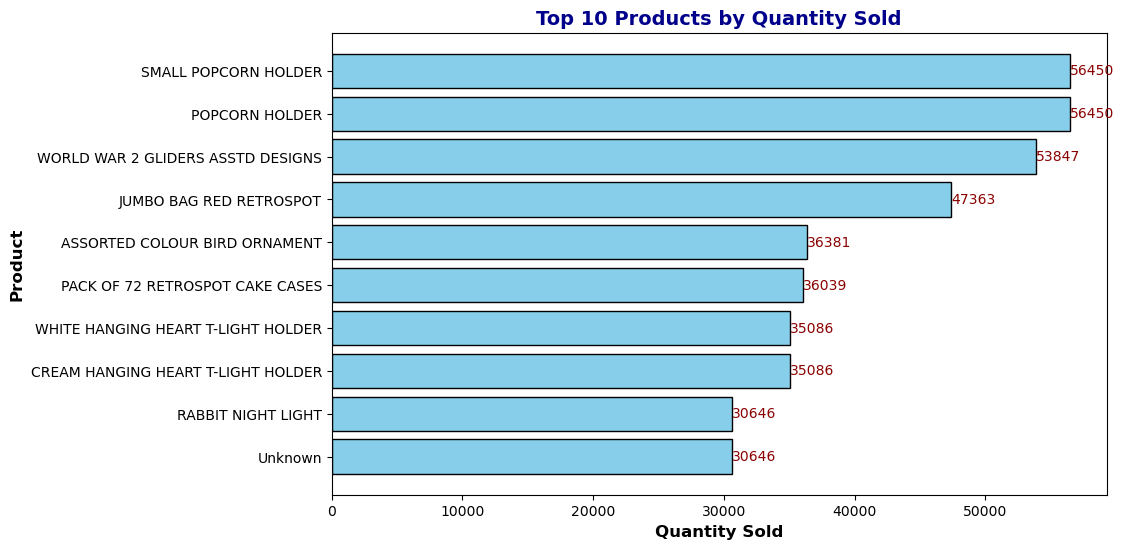

In [53]:
import matplotlib.pyplot as plt

top_selling_products_sorted = top_selling_products_sorted.iloc[:10][::-1]

plt.figure(figsize=(10, 6))
plt.barh(top_selling_products_sorted["Description"], top_selling_products_sorted["Quantity"], color="skyblue", edgecolor="black")

for index, value in enumerate(top_selling_products_sorted["Quantity"]):
    plt.text(value, index, str(value), va="center", ha="left", fontsize=10, color="darkred")

plt.xlabel("Quantity Sold", fontsize=12, fontweight="bold")
plt.ylabel("Product", fontsize=12, fontweight="bold")
plt.title("Top 10 Products by Quantity Sold", fontsize=14, fontweight="bold", color="darkblue")
plt.gca().invert_yaxis()
plt.show()


In [57]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']
top_products_revenue = df.groupby('Description').agg({'Revenue':'sum'}).reset_index()
top_products_revenue_sorted = top_products_revenue.sort_values(by='Revenue', ascending = False)

In [58]:
top_products_revenue_sorted.head(10)

,Description,Revenue
1097,DOTCOM POSTAGE,206245.48
2914,REGENCY CAKESTAND 3 TIER,164762.19
3918,WHITE HANGING HEART T-LIGHT HOLDER,99668.47
2470,PARTY BUNTING,98302.98
1865,JUMBO BAG RED RETROSPOT,92356.03
2802,RABBIT NIGHT LIGHT,66756.59
2752,POSTAGE,66230.64
2438,PAPER CHAIN KIT 50'S CHRISTMAS,63791.94
243,ASSORTED COLOUR BIRD ORNAMENT,58959.73
772,CHILLI LIGHTS,53768.06


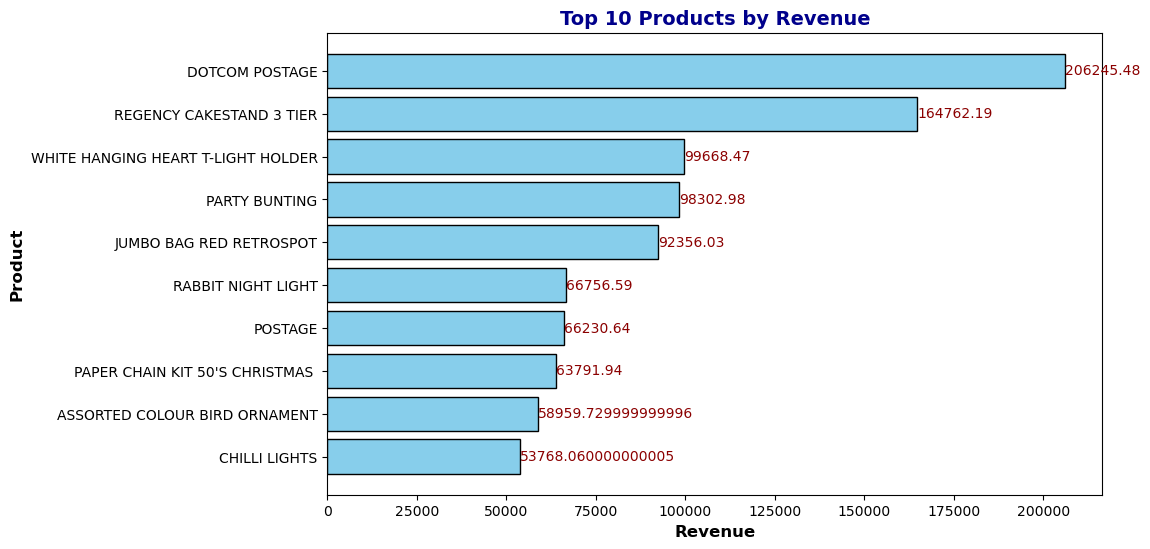

In [63]:
top_products_revenue_sorted = top_products_revenue_sorted.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_products_revenue_sorted["Description"], top_products_revenue_sorted["Revenue"], color="skyblue", edgecolor="black")

for index, value in enumerate(top_products_revenue_sorted["Revenue"]):
    plt.text(value, index, str(value), va="center", ha="left", fontsize=10, color="darkred")

plt.xlabel("Revenue", fontsize=12, fontweight="bold")
plt.ylabel("Product", fontsize=12, fontweight="bold")
plt.title("Top 10 Products by Revenue", fontsize=14, fontweight="bold", color="darkblue")

plt.gca().invert_yaxis()

plt.show()


In [65]:
sales_by_country = df.groupby('Country')['Revenue'].sum()
sales_by_country

Country
Australia                137077.270
Austria                   10154.320
Bahrain                     548.400
Belgium                   40910.960
Brazil                     1143.600
Canada                     3666.380
Channel Islands           20086.290
Cyprus                    12946.290
Czech Republic              707.720
Denmark                   18768.140
EIRE                     263276.820
European Community         1291.750
Finland                   22326.740
France                   197403.900
Germany                  221698.210
Greece                     4710.520
Hong Kong                 10117.040
Iceland                    4310.000
Israel                     7907.820
Italy                     16890.510
Japan                     35340.620
Lebanon                    1693.880
Lithuania                  1661.060
Malta                      2505.470
Netherlands              284661.540
Norway                    35163.460
Poland                     7213.140
Portugal            

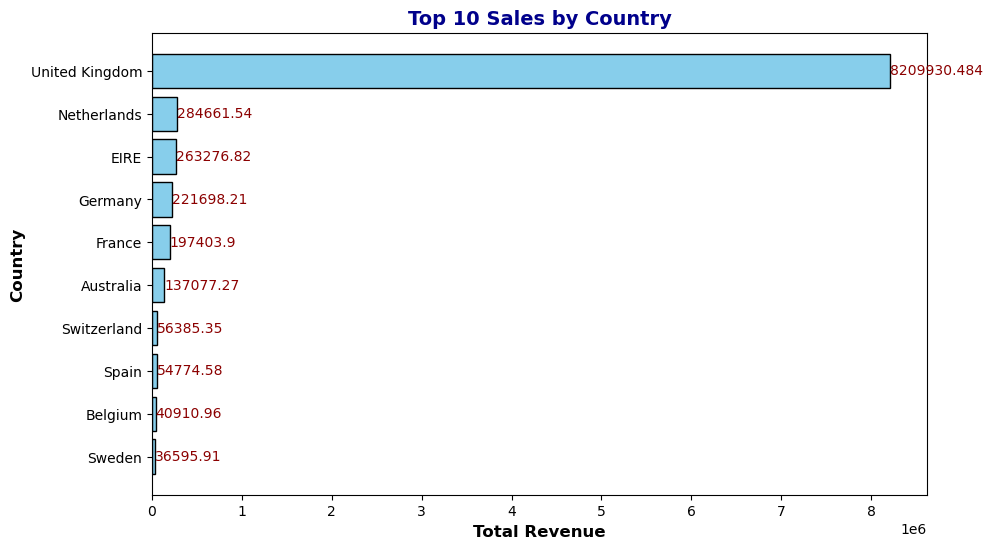

In [70]:

sales_by_country_df = sales_by_country.reset_index()

sales_by_country_sorted = sales_by_country_df.sort_values(by="Revenue", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(sales_by_country_sorted["Country"], sales_by_country_sorted["Revenue"], color="skyblue", edgecolor="black")

for index, value in enumerate(sales_by_country_sorted["Revenue"]):
    plt.text(value, index, str(value), va="center", ha="left", fontsize=10, color="darkred")

plt.xlabel("Total Revenue", fontsize=12, fontweight="bold")
plt.ylabel("Country", fontsize=12, fontweight="bold")
plt.title("Top 10 Sales by Country", fontsize=14, fontweight="bold", color="darkblue")

plt.gca().invert_yaxis()

plt.show()
